# The CUSUM Control Chart
### STAT 7110 — Quality Control
**Dr. Austin R. Brown**  
*Kennesaw State University*


In [ ]:
## Clone your forked repository to Colab ##

## Specify your user name (change to your own):

#user_name <- "abrown9008"

## Set web address to forked repository (change to your own):

#repo_address <- paste0("www.github.com/", user_name, "/STAT-7110-Quality-Control")

## Check to see if repo is already cloned to Colab, and if not, clone repo:

#if(!dir.exists("STAT-7110-Quality-Control")) {
#  system(paste0("git clone ", repo_address))
#} else {
#  print("Repository already cloned to Colab.")
#}

## Set working drive to today's lecture:

#setwd("Slides//Week-4-CUSUM")

## Introduction

- To this point, we have been discussing the use of Shewhart $\bar{X}$ and R/s control charts for monitoring a univariate process' location (mean) and dispersion (variation).

- Examining the $\bar{X}$ chart specifically, this chart is useful in both its ease of implementation and interpretability as well as its ability to detect large shifts in the process mean ($>2\sigma$).

- However, the $\bar{X}$ chart is **not** sensitive to small shifts in the process mean, which can be problematic in many applications.

- So if we are interested in efficiently (as measured by ARL) detecting smaller shifts in the process mean ($\leq 2\sigma$), we need to consider alternative control charts.

- Additionally, we have also seen that the $\bar{X}$ chart is not effective when $n=1$.

- Moreover, since we assume the individual time points are independent, we are using the information of the whole sequence of points in an inefficient manner.

- To get around these problems, we can use control charts that incorporate information from the entire sequence of points, that are effective when $n=1$, and that are sensitive to small shifts in the process mean.

- In this lecture, we will discuss the first of two such control charts: the **Cumulative Summation (CUSUM)** chart. (Next week, we will cover the **Exponentially Weighted Moving Average (EWMA)** chart.)

## The CUSUM Chart — Motivation

![Limitation of Shewhart Chart](https://raw.githubusercontent.com/abrown9008/STAT-7110-Quality-Control/main/Slides/Week-4-CUSUM/Shewhartlimitation.JPG)

- As we can see in this prior example, the first 20 observations come from a normal distribution with mean 10 and standard deviation 1. The following 10 come from a normal distribution with mean 11 and standard deviation 1.

- If we only rely upon the control limits, we would not stop the process to search for an assignable cause despite a shift having taken place.

- So how does the CUSUM chart solve this problem?

## The CUSUM Chart

- The CUSUM chart was proposed by [Page (1954)](https://academic.oup.com/biomet/article-abstract/41/1-2/100/456627?redirectedFrom=fulltext). Here's the concept:

- Let's say we want to monitor the mean of a process and this process has a target value, say $\mu_0$. To monitor the process, we still take random samples and obtain an estimate of the sample mean, say $\bar{x}_i$.

- Instead of plotting the individual value of $\bar{x}_i$ itself, we take the deviance between the target value and the sample mean, $\bar{x}_i - \mu_0$.

## The CUSUM Chart

- Then, the cumulative summation component is that the plotting statistic is a function of the cumulative sum of the deviances.

$$ C_i = \sum_{j=1}^{i}(\bar{x}_i - \mu_0) $$

- Here, the idea is that if the process starts to drift upwards or downwards, those cumulative differences will eventually signal to us that a shift has occurred. Notice that we are taking all $\bar{x}_i$'s into consideration instead of just the latest one!

- What you'll likely notice from the previous $C_i$ is that its distribution is *non-stationary*. If you're familiar with time series analysis, you'll know that this means that either the mean or the variance change with time.

- If we assume $\bar{x}_i$ is normally distributed with mean $\mu_0$ and variance $\sigma^2/n$, then:

$$ C_i = \sum_{j=1}^{i}(\bar{x}_i - \mu_0) \;\dot\sim\; N\bigg(0, \frac{i\sigma^2}{n}\bigg) $$

- This may serve as a limitation if we were to construct control limits in a Shewhart-style manner, as the limits will change over time and also won't approach an asymptote.

- Consequently, there have been two proposed variants to the CUSUM chart to help solve this problem, but we will only focus on the one that's mostly used in practice: the **Tabular CUSUM**.

## The CUSUM Chart — Tabular CUSUM

- The plotting statistic for the Tabular CUSUM is actually two statistics, an upper and a lower CUSUM:

$$ C^{+}_i = \max\big[0,\; \bar{x}_i - (\mu_0 + K) + C_{i-1}^{+}\big] $$
$$ C^{-}_i = \max\big[0,\; (\mu_0 - K) - \bar{x}_i + C_{i-1}^{-}\big] $$

where $C^+_{0} = C^{-}_{0} = 0$ and $K$ is referred to as the "slack" or "allowance" value.

## The CUSUM Chart — Choosing $K$

- Typically, $K$ is chosen to be the midpoint between our target value, $\mu_0$, and an out-of-control value, $\mu_1$, that we're interested in quickly detecting:

$$ K = \frac{|\mu_1 - \mu_0|}{2} $$

- $C^{+}$ is for detecting upward shifts ($\mu_1 > \mu_0$) and $C^{-}$ is for detecting downward shifts ($\mu_1 < \mu_0$).

- If either $C^{+}_i$ or $C^{-}_i$ exceed some control limit, say $H$, this signals to us that the process may be out of control (OOC).

## The CUSUM Chart — Choosing $H$

- What about $H$? How do we decide its value?

- Typically, $H$ is chosen to be a multiple of the standard deviation of the process, $\sigma$.

- The rule of thumb is to set $H = h\sigma$, where $h = 4$ or $5$.

## The CUSUM Chart in R

- Let's see how we can implement the CUSUM chart in R.

- In this example, suppose we are filling soda bottles. The target fill is $\mu_0 = 16$ oz.

- Suppose we take a sample of 5 bottles every hour for two days (48 hours).
  - Let's define $K = 0.5$ and $H = 5$.

In [4]:
## Load the Libraries ##

library(tidyverse)
library(readxl)
library(qcc)

── Attaching core tidyverse packages ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   4.0.0     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the ]8;;http://conflicted.r-lib.org/conflicted package]8;; to force all conflicts to become errors


Warning message:
package ‘tidyverse’ was built under R version 4.5.3 
Warning message:
package ‘readxl’ was built under R version 4.5.3 


  __ _  ___ ___ 
 / _  |/ __/ __|  Quality Control Charts and 
| (_| | (_| (__   Statistical Process Control
 \__  |\___\___|
    |_|           version 2.7
Type 'citation("qcc")' for citing this R package in publications.


Warning message:
package ‘qcc’ was built under R version 4.5.3 


### Read in the Soda Bottles data

In [5]:
bottles <- read_xlsx("Soda Bottles.xlsx")

bottles |>
  glimpse()

Rows: 48
Columns: 5
$ `Bottle 1` <dbl> 15.78, 16.35, 16.03, 16.08, 16.10, 16.14, 16.09, 16.13, 16.10, 15.85, 15.98, 16.45, 16.08, 16.28, 16.00, 16.38, 16.23, 16.31, 15.98, 16.23, 15.75, 16.34, 1…
$ `Bottle 2` <dbl> 16.14, 16.05, 16.19, 16.31, 16.55, 16.22, 16.13, 16.18, 16.22, 15.92, 15.89, 16.35, 16.00, 16.15, 16.13, 16.12, 15.99, 16.41, 16.69, 16.50, 16.32, 16.13, 1…
$ `Bottle 3` <dbl> 15.94, 15.80, 16.08, 15.96, 16.06, 15.98, 15.92, 16.44, 16.32, 16.18, 16.35, 16.02, 16.69, 16.43, 15.92, 16.45, 16.31, 15.89, 15.95, 15.81, 15.97, 16.27, 1…
$ `Bottle 4` <dbl> 16.19, 16.12, 16.38, 16.13, 16.23, 16.24, 16.42, 16.32, 16.33, 16.01, 15.98, 16.14, 16.48, 15.83, 16.44, 16.29, 16.43, 16.08, 16.37, 16.53, 15.86, 16.11, 1…
$ `Bottle 5` <dbl> 16.53, 16.03, 16.29, 16.28, 16.26, 15.76, 16.40, 16.20, 16.27, 16.29, 15.86, 16.39, 16.21, 16.03, 16.31, 16.68, 16.13, 16.45, 16.39, 16.03, 15.99, 16.25, 1…


### Calculate sample means & overall SD

In [6]:
bottles_means <- rowMeans(bottles)
sigma_hat <- sd.xbar(bottles,std.dev="UWAVE-SD")

mu0 <- 16

### Standardize the row means

In [7]:
z_means <- (bottles_means - mu0)/(sigma_hat/sqrt(5))

### Calculate the CUSUM values manually before using the `qcc` function

In [8]:
k <- 0.5
h <- 5

CUSUM_df <- tibble(Means = z_means)

## Calculate C+ and C- values prior to taking maximums ##

CUSUM_df <- CUSUM_df |>
  mutate(C_plus = Means-k,
         C_minus = -k-Means)

### Create a loop to accumulate $C^+$ and $C^-$

In [9]:
c_plus <- vector('double',length=nrow(CUSUM_df))
c_minus <- vector('double',length=nrow(CUSUM_df))

for(i in 1:length(c_plus)){
  
  if(i==1){
    
    c_plus[i] <- max(0,CUSUM_df$C_plus[i])
    c_minus[i] <- max(0,CUSUM_df$C_minus[i])
    
  } else {
    
    c_plus[i] <- max(0,CUSUM_df$C_plus[i] + c_plus[i-1])
    c_minus[i] <- max(0,CUSUM_df$C_minus[i] + c_minus[i-1])
    
  }
  
}

### Plot the manually-calculated CUSUM chart

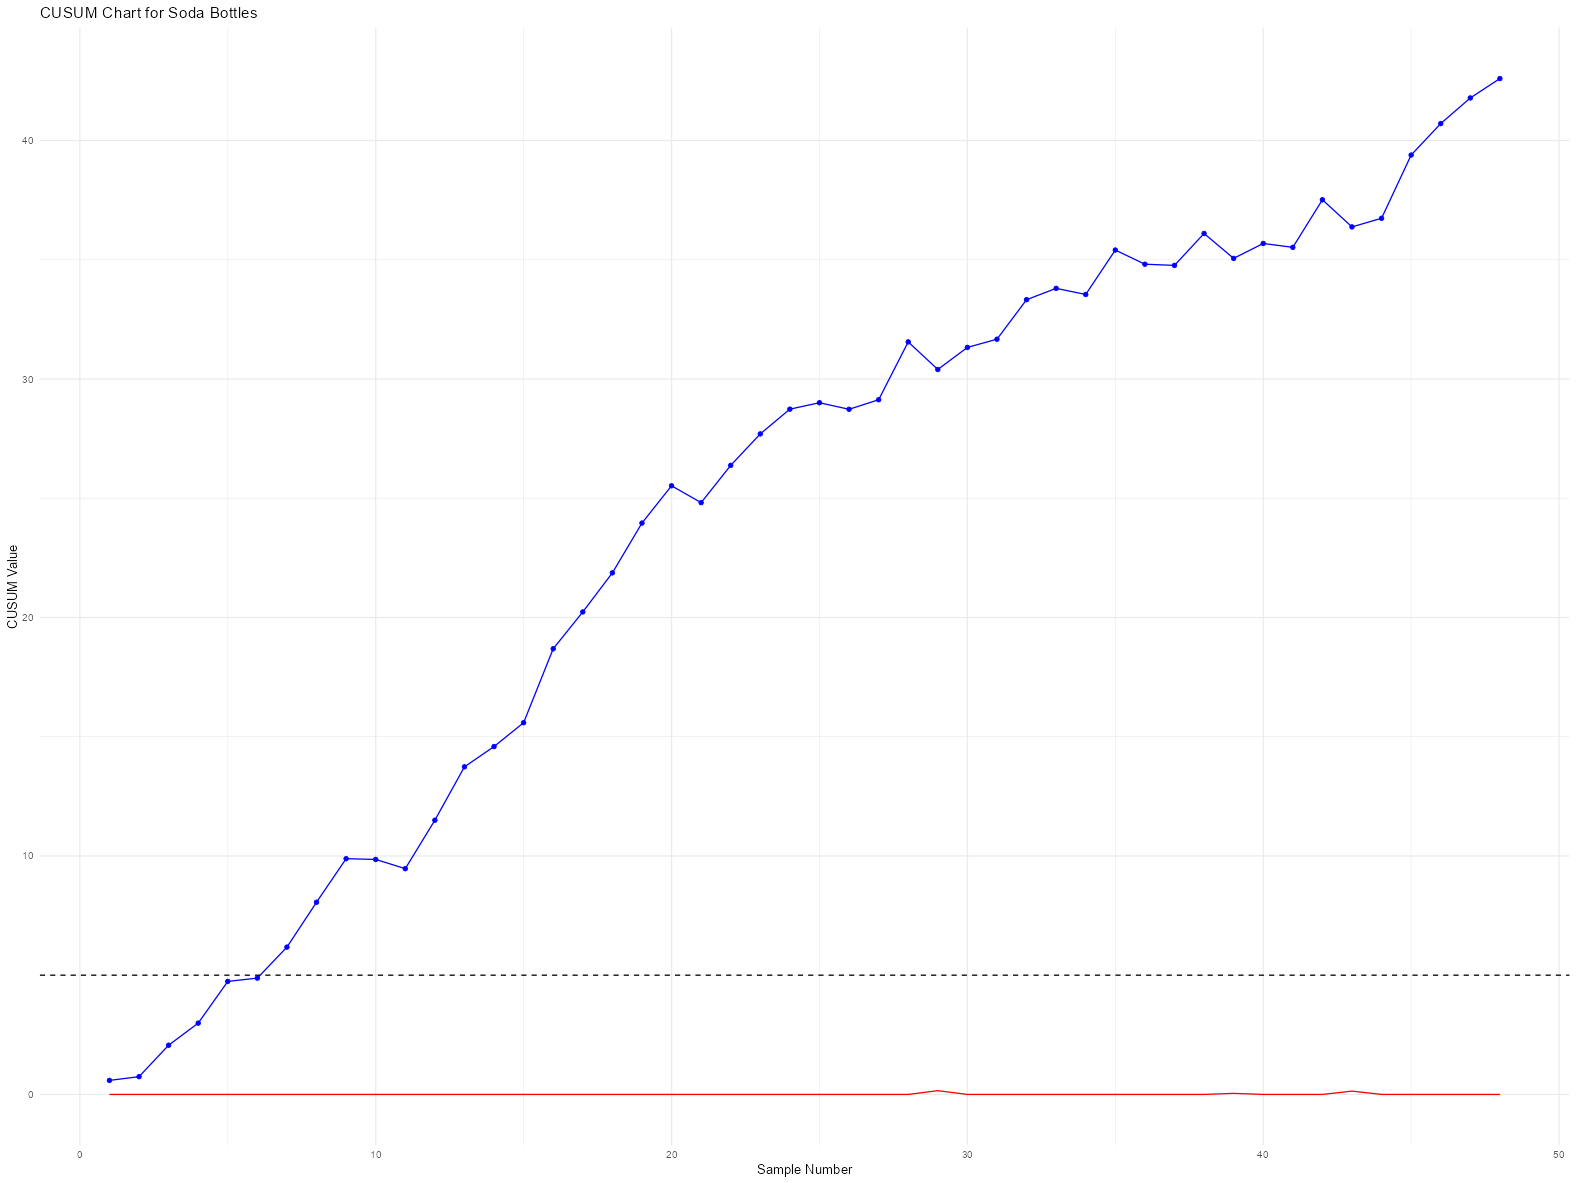

In [10]:
CUSUM_df <- CUSUM_df |>
  mutate(C_plus1 = c_plus,
         C_minus1 = c_minus)

CUSUM_df |>
  ggplot(aes(x=1:nrow(CUSUM_df))) +
  geom_line(aes(y=C_plus1),color="blue") +
  geom_point(aes(y=C_plus1),color='blue') +
  geom_line(aes(y=C_minus1),color="red") +
  geom_hline(yintercept=h,linetype="dashed") +
  labs(title="CUSUM Chart for Soda Bottles",
       x="Sample Number",
       y="CUSUM Value") +
  theme_minimal()

### Now how do we do this using the `qcc` package?

Note: `qcc` wants to standardize the data, so we need to be mindful of this.

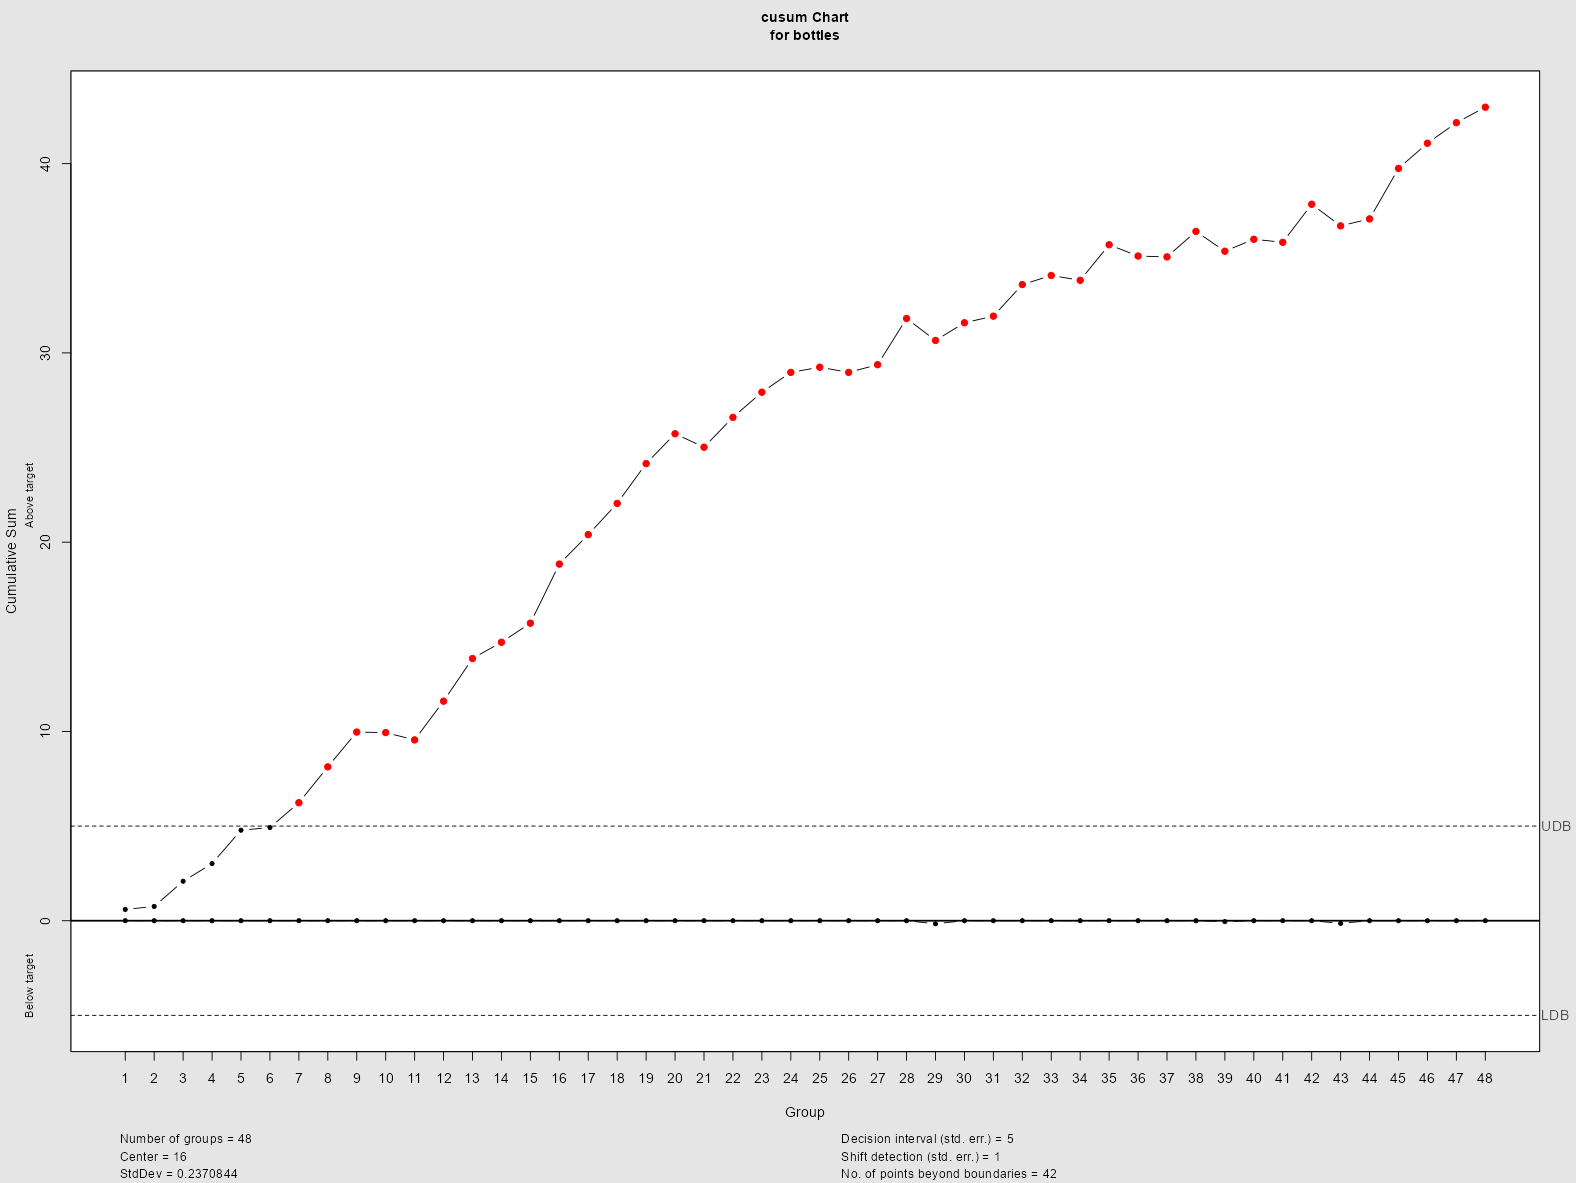

List of 14
 $ call             : language cusum(data = bottles, sizes = 5, center = mu0, decision.interval = h, se.shift = k * 2, plot = T)
 $ type             : chr "cusum"
 $ data.name        : chr "bottles"
 $ data             : num [1:48, 1:5] 15.8 16.4 16 16.1 16.1 ...
  ..- attr(*, "dimnames")=List of 2
 $ statistics       : Named num [1:48] 16.1 16.1 16.2 16.2 16.2 ...
  ..- attr(*, "names")= chr [1:48] "1" "2" "3" "4" ...
 $ sizes            : num [1:48] 5 5 5 5 5 5 5 5 5 5 ...
 $ center           : num 16
 $ std.dev          : num 0.237
 $ pos              : num [1:48] 0.594 0.754 2.084 3.018 4.781 ...
 $ neg              : num [1:48] 0 0 0 0 0 0 0 0 0 0 ...
 $ head.start       : num 0
 $ decision.interval: num 5
 $ se.shift         : num 1
 $ violations       :List of 2
 - attr(*, "class")= chr "cusum.qcc"

In [11]:
cusum(bottles,sizes=5,center=mu0,se.shift=k*2,
      decision.interval = h,plot=T)

This lets us know that the process is **not** in control for $\mu_0 = 16$, as the upper CUSUM values exceed the decision interval.

## CUSUM Chart Design

- In the last example, we used a CUSUM control chart where $H=5$ and $K=0.50$. How do we choose those values?

- Generally, the rule of thumb is to define $H = h\sigma$ and $K = k\sigma$, where $h=4$ or $5$ and $k=0.50$. So for a given known or estimated value of $\sigma$, we can obtain $H$ and $K$.
  - Note, in our example we standardized our sample means using the estimated standard deviation, so we were able to just use $H=5$ and $K=0.50$.

## CUSUM Chart Design — ARL Curve

![CUSUM ARL Curve]((https://raw.githubusercontent.com/abrown9008/STAT-7110-Quality-Control/main/Slides/Week-4-CUSUM/CUSUM_ARL.JPG))

## CUSUM Chart Usage

- So far we have seen that CUSUM can be used for monitoring sample means when $n \geq 1$.

- However, CUSUM can be used for other statistics as well, including the sample standard deviation, sample proportions, number of nonconforming items, etc.

- It can also be used for variable sample sizes by standardizing observations, like we did in the soda bottles example.

## CUSUM ARL Estimation

- Unlike the Shewhart-style charts, the plotting statistics for the CUSUM chart are not independent of each other. Thus, the typical $ARL_0 = 1/\alpha$ and $ARL_1 = 1/(1-\beta)$ calculations aren't valid.

- Estimating ARL for CUSUM charts can be quite complicated. However, we do have some rough estimates that we can use in Phase I when making decisions about chart construction.

- For a one-sided CUSUM, Siegmund (1985) provided an approximation:

$$ ARL = \frac{\exp(-2\Delta b) + 2\Delta b - 1}{2\Delta^2} $$

- where $\Delta = \delta^* - k$ for the upper CUSUM, $\Delta = -\delta^* - k$ for the lower CUSUM, $b = h + 1.166$, and $\delta^* = (\mu_1 - \mu_0)/\sigma$.

- Then, if we're using a two-sided CUSUM, we can estimate the overall ARL by:

$$ \frac{1}{ARL} = \frac{1}{ARL^{+}} + \frac{1}{ARL^{-}} $$

In general, the ARL for a CUSUM with $k=0.5$ and $h=5$ is:

| Shift in Mean | $ARL$ |
|:---:|:---:|
| 0 | 465 |
| 0.25 | 139 |
| 0.50 | 38 |
| 0.75 | 17 |
| 1.00 | 10.4 |
| 2.00 | 4.01 |
| 3.00 | 2.57 |


## CUSUM — Additional Example: $n = 1$ (Customer Hold Times)

CUSUM also works when we have individual observations ($n=1$), not just sample means. Let's monitor the amount of time customers spend on hold at a customer service support center, where the target hold time is $\mu_0 = 10$ minutes and $\sigma = 1$ minute.

In [12]:
customer_hold <- read_xlsx("EWMA Datasets.xlsx",sheet=1)

customer_hold |>
  glimpse()

Rows: 30
Columns: 2
$ Call <dbl> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30
$ Time <dbl> 9.45, 7.99, 9.29, 11.66, 12.16, 10.18, 8.04, 11.46, 9.20, 10.34, 9.03, 11.47, 10.51, 9.40, 10.08, 9.37, 10.62, 10.31, 8.52, 10.84, 10.90, 9.33, 12.29, 11.50, 10.…


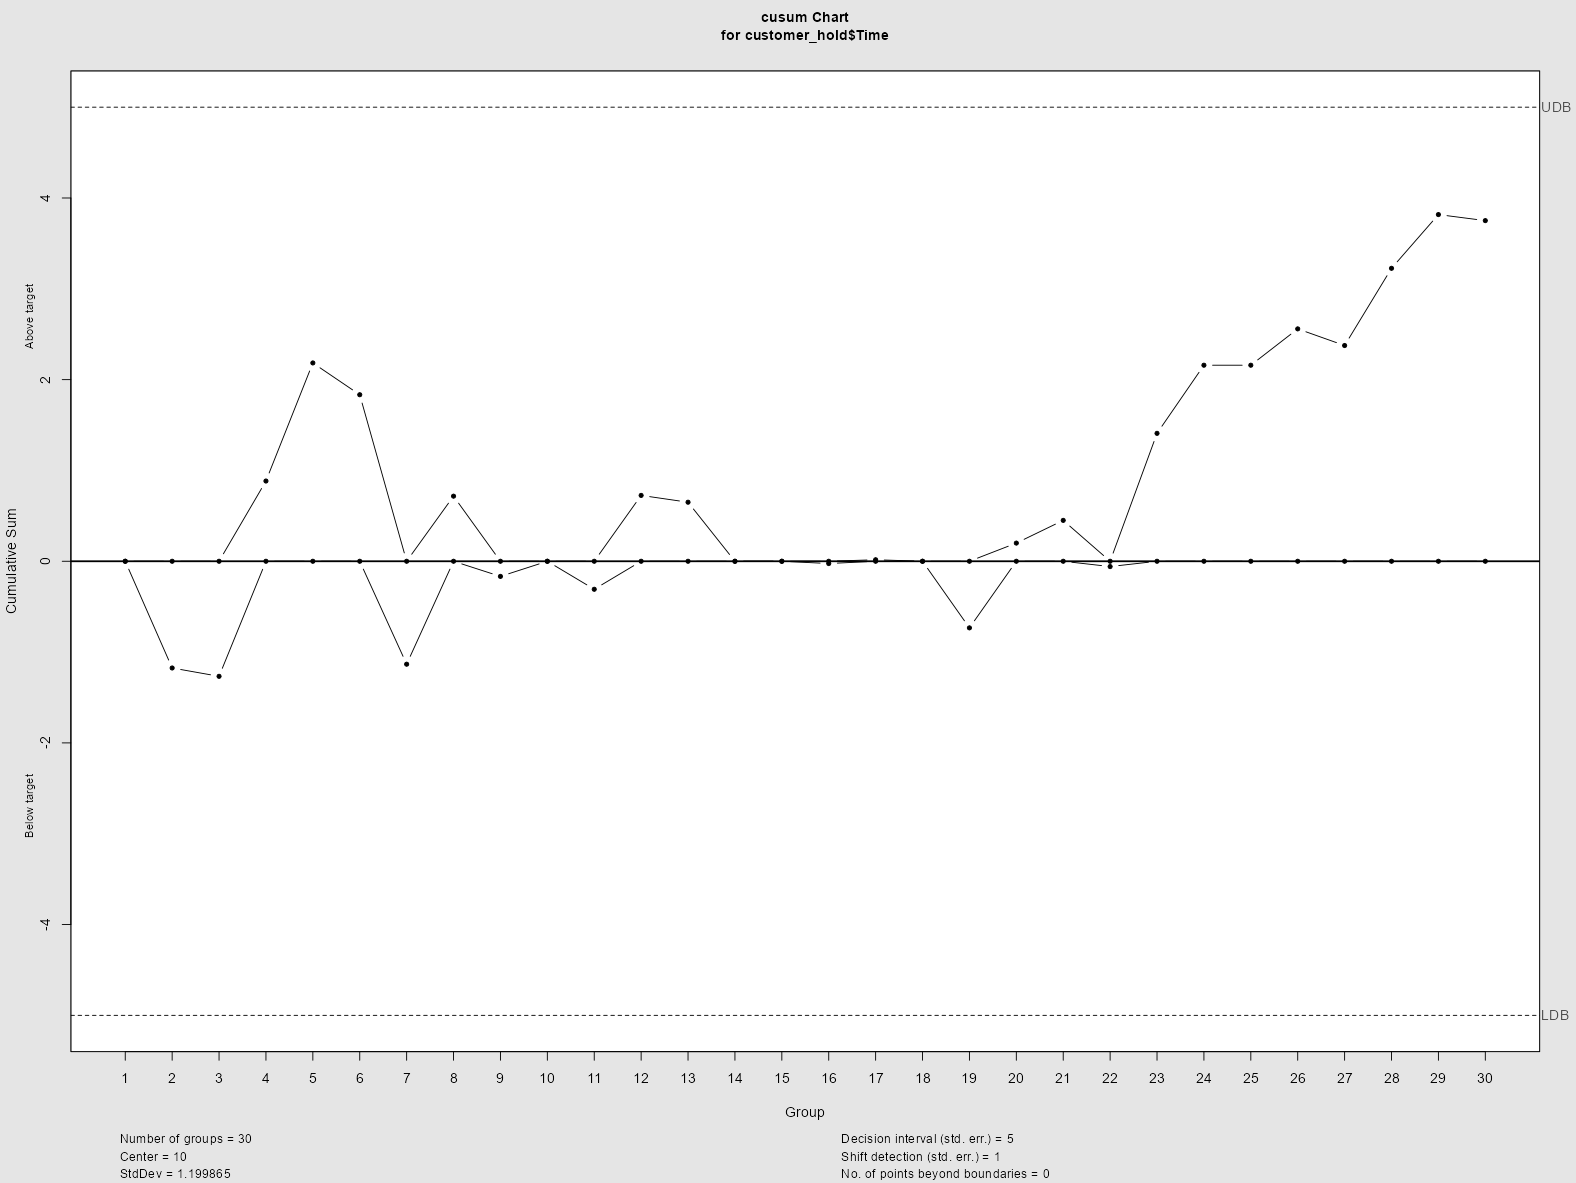

List of 14
 $ call             : language cusum(data = customer_hold$Time, sizes = 1, center = 10, decision.interval = 5, se.shift = k * 2, plot = T, sigma = 1)
 $ type             : chr "cusum"
 $ data.name        : chr "customer_hold$Time"
 $ data             : num [1:30, 1] 9.45 7.99 9.29 11.66 12.16 ...
  ..- attr(*, "dimnames")=List of 2
 $ statistics       : Named num [1:30] 9.45 7.99 9.29 11.66 12.16 ...
  ..- attr(*, "names")= chr [1:30] "1" "2" "3" "4" ...
 $ sizes            : num [1:30] 1 1 1 1 1 1 1 1 1 1 ...
 $ center           : num 10
 $ std.dev          : num 1.2
 $ pos              : num [1:30] 0 0 0 0.883 2.184 ...
 $ neg              : num [1:30] 0 -1.18 -1.27 0 0 ...
 $ head.start       : num 0
 $ decision.interval: num 5
 $ se.shift         : num 1
 $ violations       :List of 2
 - attr(*, "class")= chr "cusum.qcc"

In [13]:
cusum(customer_hold$Time,sizes=1,center=10,sigma=1,
      se.shift=k*2,decision.interval = 5,plot=T)

## CUSUM — Additional Example: Fuel Costs

Suppose we're the Scranton branch of Dunder-Mifflin. In order for our branch to be profitable, we need to maximize sales and control our operating costs. One such operating cost is the amount of fuel our warehouse delivery trucks use. In the second sheet of this week's class data, we have the past 24 months of fuel costs. Here we don't know the process mean and standard deviation, so we'll estimate them and check whether the process is in control.

In [14]:
fuel_costs <- read_xlsx("EWMA Datasets.xlsx",sheet=2)

fuel_costs |>
  glimpse()

Rows: 24
Columns: 2
$ Cost  <dbl> 5525.27, 5084.35, 4021.17, 4923.73, 5254.42, 5404.45, 4843.34, 5317.60, 5432.54, 5296.34, 4879.27, 4686.64, 4562.50, 5058.12, 5400.74, 4474.92, 4178.80, 4696.50…
$ month <dbl> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12


### Estimate the process mean and standard deviation

In [15]:
## Estimate process mean ##

mu0 <- mean(fuel_costs$Cost)

## Estimate process standard deviation ##

sigma_hat <- sd(fuel_costs$Cost)

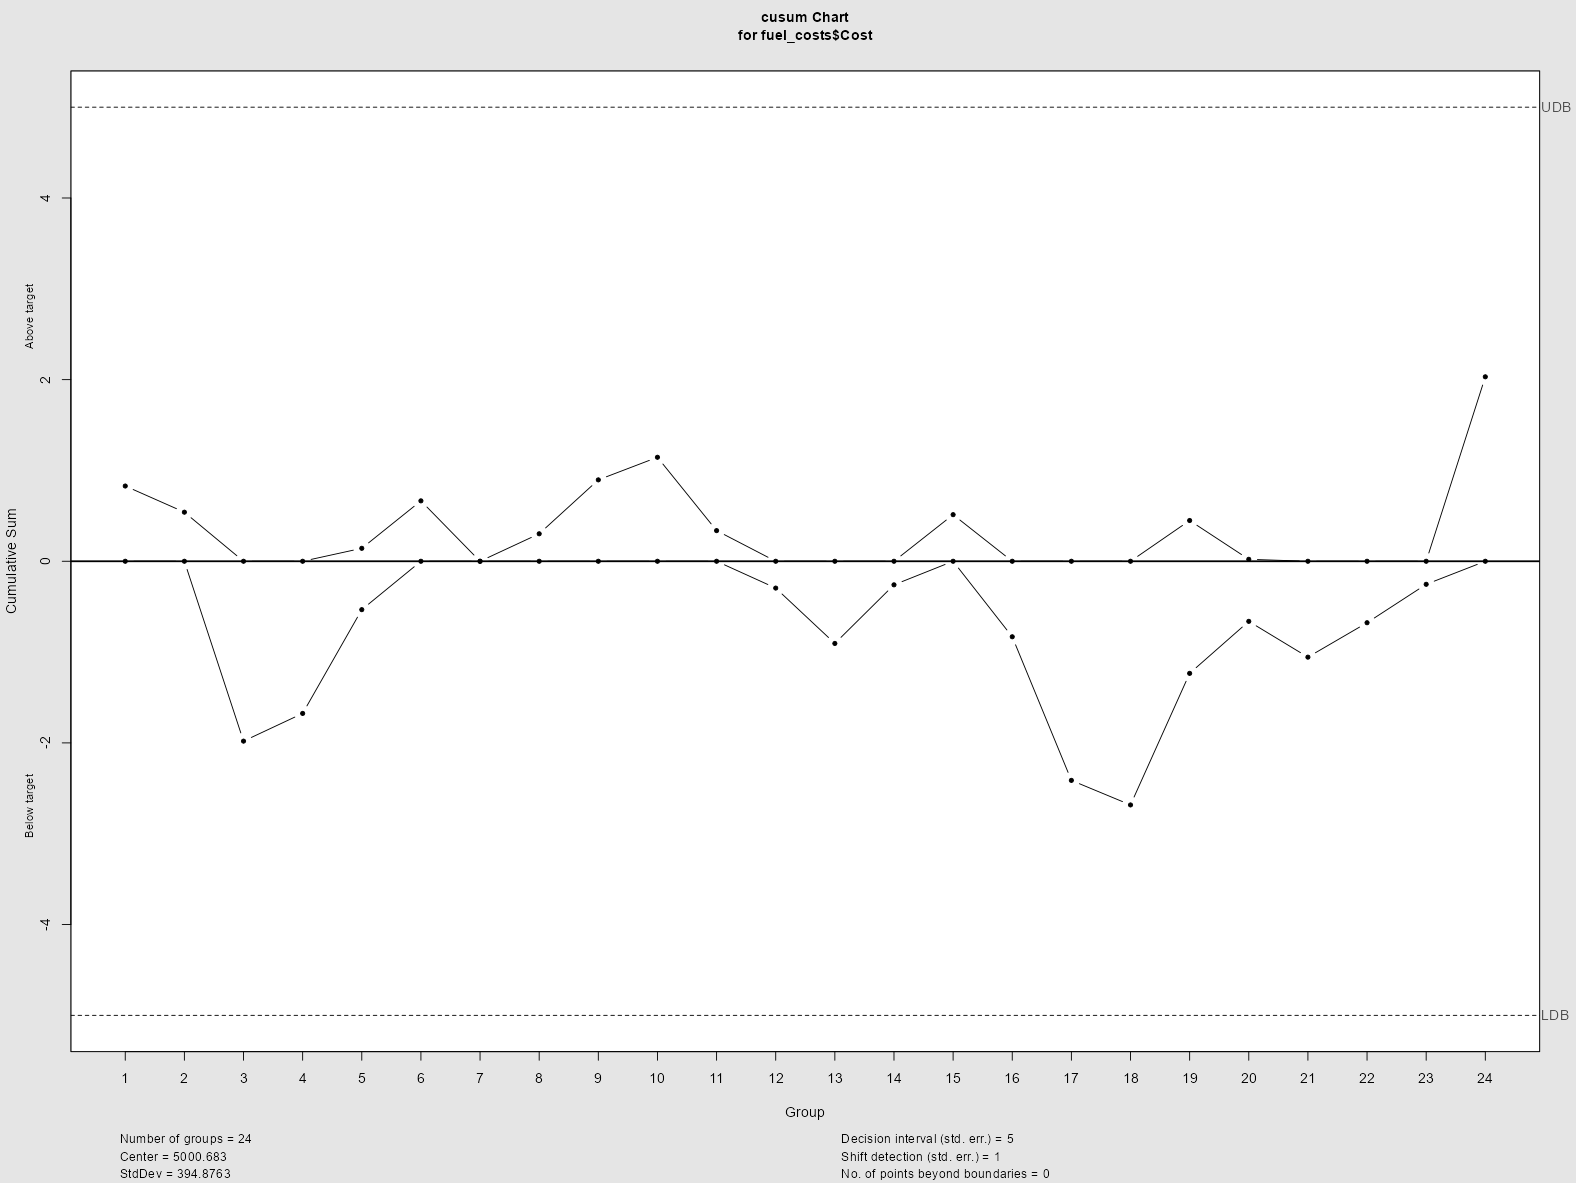

List of 14
 $ call             : language cusum(data = fuel_costs$Cost, sizes = 1, center = mu0, decision.interval = 5, se.shift = k * 2, plot = T, sigma = sigma_hat)
 $ type             : chr "cusum"
 $ data.name        : chr "fuel_costs$Cost"
 $ data             : num [1:24, 1] 5525 5084 4021 4924 5254 ...
  ..- attr(*, "dimnames")=List of 2
 $ statistics       : Named num [1:24] 5525 5084 4021 4924 5254 ...
  ..- attr(*, "names")= chr [1:24] "1" "2" "3" "4" ...
 $ sizes            : num [1:24] 1 1 1 1 1 1 1 1 1 1 ...
 $ center           : num 5001
 $ std.dev          : num 395
 $ pos              : num [1:24] 0.828 0.54 0 0 0.143 ...
 $ neg              : num [1:24] 0 0 -1.981 -1.675 -0.533 ...
 $ head.start       : num 0
 $ decision.interval: num 5
 $ se.shift         : num 1
 $ violations       :List of 2
 - attr(*, "class")= chr "cusum.qcc"

In [16]:
cusum(fuel_costs$Cost,sizes=1,center=mu0,sigma=sigma_hat,
      se.shift=k*2,decision.interval = 5,plot=T)

It appears that the process is in control using the estimated mean and standard deviation.

## CUSUM Limitations

- As you can probably tell, the CUSUM chart is not without limitations.

- Compared to the Shewhart $\bar{X}$ chart, the CUSUM chart is more complex to implement and interpret.

- It may also be less evident how to set the control limits, $H$ and $K$.

- So how do we take the advantages of the CUSUM and combine them with the simplicity of the Shewhart $\bar{X}$ chart? *(This is where the EWMA chart comes in — see next week's notebook!)*